In [1]:
from qiskit.circuit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager, PassManager
from qiskit.transpiler.passes.scheduling import ALAPScheduleAnalysis, PadDynamicalDecoupling, ASAPScheduleAnalysis
from qiskit_ibm_runtime.fake_provider import FakeBrisbane 
from qiskit.providers.backend import BackendV2 as Backend
from qiskit_ibm_runtime.sampler import SamplerOptions, SamplerV2 as Sampler
from qiskit_ibm_runtime import Batch, QiskitRuntimeService
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import XGate 
from qiskit.quantum_info import hellinger_fidelity
import numpy as np
import pandas as pd 
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit.circuit.equivalence_library import (SessionEquivalenceLibrary as sel,)
from qiskit.transpiler.passes import BasisTranslator


In [2]:
def prepare_ghz(n_qubits:int):
    ## Prepares standard ghz state with measurements on all qubits using measure_all() 
    circuit = QuantumCircuit(n_qubits)
    circuit.h(0)
    for i in range(0, n_qubits-1):
        circuit.cx(i, i+1)

    circuit.measure_all()

    return circuit

def prepare_echo_ghz_with_xs(n_qubits:int):
    ## Prepares echo circuit with for ghz circuit. Xs at the end to make the expectation value 1. 
    circuit = QuantumCircuit(n_qubits)
    circuit.h(0)
    for i in range(0, n_qubits-1):
        circuit.cx(i, i+1)

    circuit.barrier()

    circuit.compose(circuit.inverse(), inplace=True)

    circuit.barrier()

    circuit.x(range(n_qubits))

    circuit.measure_all()

    return circuit


def naked_sampler(mode, shots=4096):
    ## Sampler with no error mitigation or supression for any mode (job, batch). ALL OPTIONS ARE DISABLED. 
    options = SamplerOptions(default_shots=shots, dynamical_decoupling={"enable": False}, twirling={"enable_gates": False, "enable_measure": False})
    sampler = Sampler(mode=mode, options=options)
    return sampler


def pm_for_backend(bknd, opt_level, seed=42069, schedueling_method="alap"):
    ## Returns a PassManager from generate_preset_pass_manager for given opt_level and backend(bknd)
    pm = generate_preset_pass_manager(optimization_level=opt_level, backend=bknd, seed_transpiler=seed, scheduling_method=schedueling_method)
    return pm


def execute_on_hardware(bknd, sampler_pub):
    ## Batch mode execution of quantum circuits on hardware
    with Batch(backend=bknd) as batch:
        sampler = naked_sampler(mode=batch, shots=4096)
        # summary = summarize_backend(bknd)
        job = sampler.run(sampler_pub)
        id = job.job_id()
        print(id)
    return id


def get_result_from_id(service, id):
    # Get Result object from service using id

    job = service.job(id)
    result = job.result()

    return result
    

def prepare_dd_pm(backend: Backend, scheduling_method="alap", seq="XX"):
    ## Returns a PassManager for DD with customizable DD sequence and scheduelling method. 
    
    # Default Sequence
    sequenece = [XGate(), XGate()]

    if seq.lower() == "xpxm":
        sequenece = [XGate(), XGate().inverse()]

    target = backend.target
    ## Prepare a preset passmanager for backend optimization_level=3
    pm = pm_for_backend(bknd=backend, opt_level=3, seed=42069)

    if scheduling_method == "alap":
        pm.scheduling.append(ALAPScheduleAnalysis(target=target))
        pm.scheduling.append(PadDynamicalDecoupling(target=target, dd_sequence=sequenece))

    elif scheduling_method == "asap":
        pm.scheduling.append(ASAPScheduleAnalysis(target=target))
        pm.scheduling.append(PadDynamicalDecoupling(target=target, dd_sequence=sequenece))
        
    return pm




def transpile_for_dd(circuit, dd_pm, backend):
    
    isa_dd_circuit = dd_pm.run(circuit)
    
    return isa_dd_circuit
    



def get_fidelity_for_circuit(ideal, simulated, dd_counts_list):

    ## Returns List[List] of hellinger fidelity results. Outer list is of length 2 and contains
    # 0 :- List of len 3 with hellinger fidelity compared to ideal counts. [hellinger_simulated, hellinger_no_dd, hellinger_dd]
    # 1 :- List of len 2 with hellinger fidelity compared to simulated counts. [hellinger_no_dd, hellinger_dd]

    # Calculating hellinger fidelity compared to ideal counts

    hellinger_results = []

    for target_result in [simulated] + dd_counts_list:

        hellinger_results.append(hellinger_fidelity(ideal, target_result))

    # Calculate hellinger fidelity compared to simulated counts

    alt_hellinger_results = []

    for target_result in dd_counts_list:
        alt_hellinger_results.append(hellinger_fidelity(simulated, target_result))



    return [hellinger_results, alt_hellinger_results]




def summarize_backend(backend):
    """Return a structured snapshot of backend properties for an online IBMBackend."""
    try:
        config = backend.configuration()
    except Exception:
        config = None

    try:
        props = backend.properties()
    except Exception:
        props = None

    num_qubits = getattr(backend, "num_qubits", None)
    if callable(num_qubits):
        num_qubits = num_qubits()

    dt = None
    if config and hasattr(config, "dt"):
        dt = getattr(config, "dt", None)
    elif getattr(backend, "dt", None):
        dt = backend.dt
    elif getattr(getattr(backend, "target", None), "dt", None):
        dt = backend.target.dt

    granularity = None
    if config and getattr(config, "timing_constraints", None):
        granularity = config.timing_constraints.get("granularity")
    if granularity is None and getattr(getattr(backend, "target", None), "granularity", None):
        granularity = backend.target.granularity

    summary = {
        "backend_name": getattr(backend, "name", lambda: str(backend)),
        "num_qubits": num_qubits or (getattr(config, "num_qubits", None) if config else None),
        "basis_gates": [],
        "supported_instructions": [],
        "coupling_map": None,
        "qubit_properties": [],
        "gate_parameters": [],
        "last_update": None,
        "dt": dt,
        "granularity": granularity,
    }

    target = getattr(backend, "target", None)
    if config and getattr(config, "basis_gates", None):
        summary["basis_gates"] = list(config.basis_gates)
    elif target is not None:
        summary["basis_gates"] = list(target.operations)

    if target is not None:
        summary["supported_instructions"] = list(target.operations)

    coupling_map = None
    if config and getattr(config, "coupling_map", None):
        coupling_map = [list(edge) for edge in config.coupling_map]
    elif getattr(backend, "coupling_map", None):
        cm = backend.coupling_map
        if cm:
            coupling_map = [list(edge) for edge in cm]
    elif target is not None:
        try:
            target_map = target.build_coupling_map()
            if target_map:
                coupling_map = [list(edge) for edge in target_map.get_edges()]
        except Exception:
            pass
    summary["coupling_map"] = coupling_map

    if props:
        props_dict = props.to_dict()
        for qubit_index, qubit_props in enumerate(props_dict.get("qubits", [])):
            values = {entry["name"]: entry["value"] for entry in qubit_props}
            readout_error = values.get("readout_error")
            if readout_error is None and {"prob_meas0_prep1", "prob_meas1_prep0"}.issubset(values):
                readout_error = (values["prob_meas0_prep1"] + values["prob_meas1_prep0"]) / 2

            summary["qubit_properties"].append({
                "qubit": qubit_index,
                "t1": values.get("T1"),
                "t2": values.get("T2"),
                "frequency": values.get("frequency"),
                "readout_error": readout_error,
            })

        for gate in props_dict.get("gates", []):
            params = {param["name"]: param["value"] for param in gate.get("parameters", [])}
            summary["gate_parameters"].append({
                "gate": gate.get("gate"),
                "qubits": gate.get("qubits"),
                "gate_error": params.get("gate_error"),
                "gate_length": params.get("gate_length"),
            })

        summary["last_update"] = props_dict.get("last_update_date")

    return summary

In [3]:
qubits = [7, 8, 9, 10, 25, 30, 35]

## Circuit generation and transpilation

In [4]:
## Prepare circuit dict
circuit_dict = {f"{qubit}":prepare_echo_ghz_with_xs(n_qubits=qubit) for qubit in qubits}
circuit_dict

{'7': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x721db5954990>,
 '8': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x721db7647c50>,
 '9': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x721db73b8c90>,
 '10': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x721db5955210>,
 '25': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x721db5955450>,
 '30': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x721db5955dd0>,
 '35': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x721db5956690>}

In [ ]:
service = QiskitRuntimeService(name="qamp-2025")

management.get:WARNING:2025-12-07 02:33:41,574: Loading saved account: qamp-2025


IBMInputValueError: 'The given API token is associated with an account that does not have access to the instance crn:v1:bluemix:public:quantum-computing:us-east:a/5a8ac1c64f0f4d6bb48b2db1e866c970:3ab20cba-7b95-4368-9eeb-845203c07986::. To use this instance, use an API token generated from the account with this instance available.'

In [18]:
## Transpile circuit for marrakesh backend


marrakesh = service.backend("ibm_marrakesh")

## Transpiler with optimization_level=3
pm3 = pm_for_backend(marrakesh, 3, 42069) # args: backend, optimization_level, seed_transpiler
isa_dict = {f"{qubit}":pm3.run(circuit_dict[f"{qubit}"]) for qubit in qubits}

## Transpile for DD

dd_xpxm_pm = prepare_dd_pm(marrakesh, seq="XpXm", scheduling_method="alap")

dd_xx_pm = prepare_dd_pm(marrakesh, seq="XX", scheduling_method="alap")


isa_dd_xpxm_dict = {f"{qubit}":transpile_for_dd(circuit_dict[f"{qubit}"], dd_xpxm_pm, marrakesh) for qubit in qubits}

isa_dd_xx_dict = {f"{qubit}":transpile_for_dd(circuit_dict[f"{qubit}"], dd_xx_pm, marrakesh) for qubit in qubits}


print(isa_dict)



{'7': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7fa4498af050>, '8': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7fa449c14190>, '9': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7fa449bbb450>, '10': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7fa449cbd890>, '25': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7fa449a78d90>, '30': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7fa45442add0>, '35': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7fa453e3ebd0>}


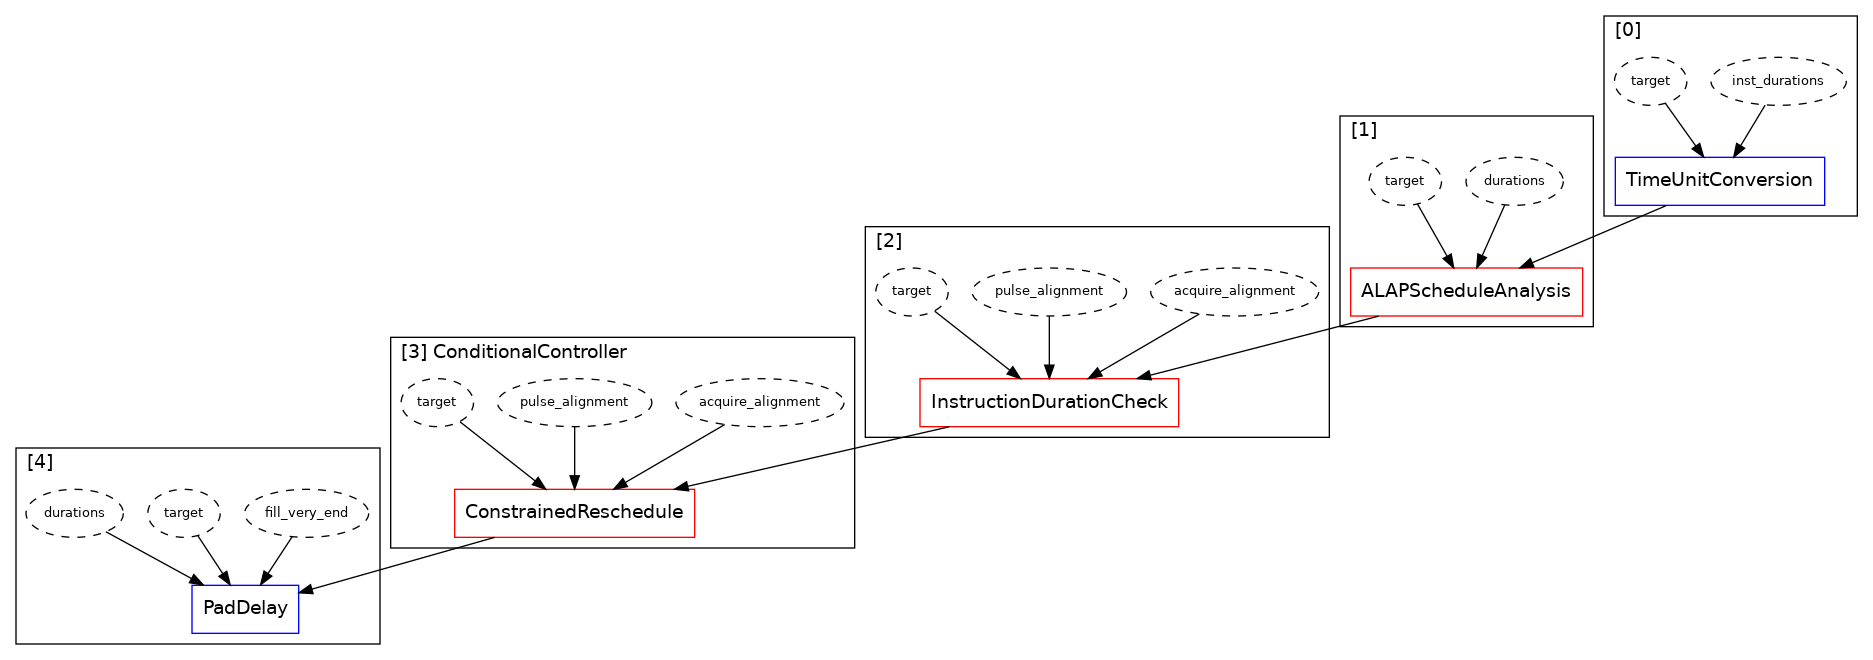

In [19]:
## PM (Scheduling) for no DD circuit.
pm3.scheduling.draw()

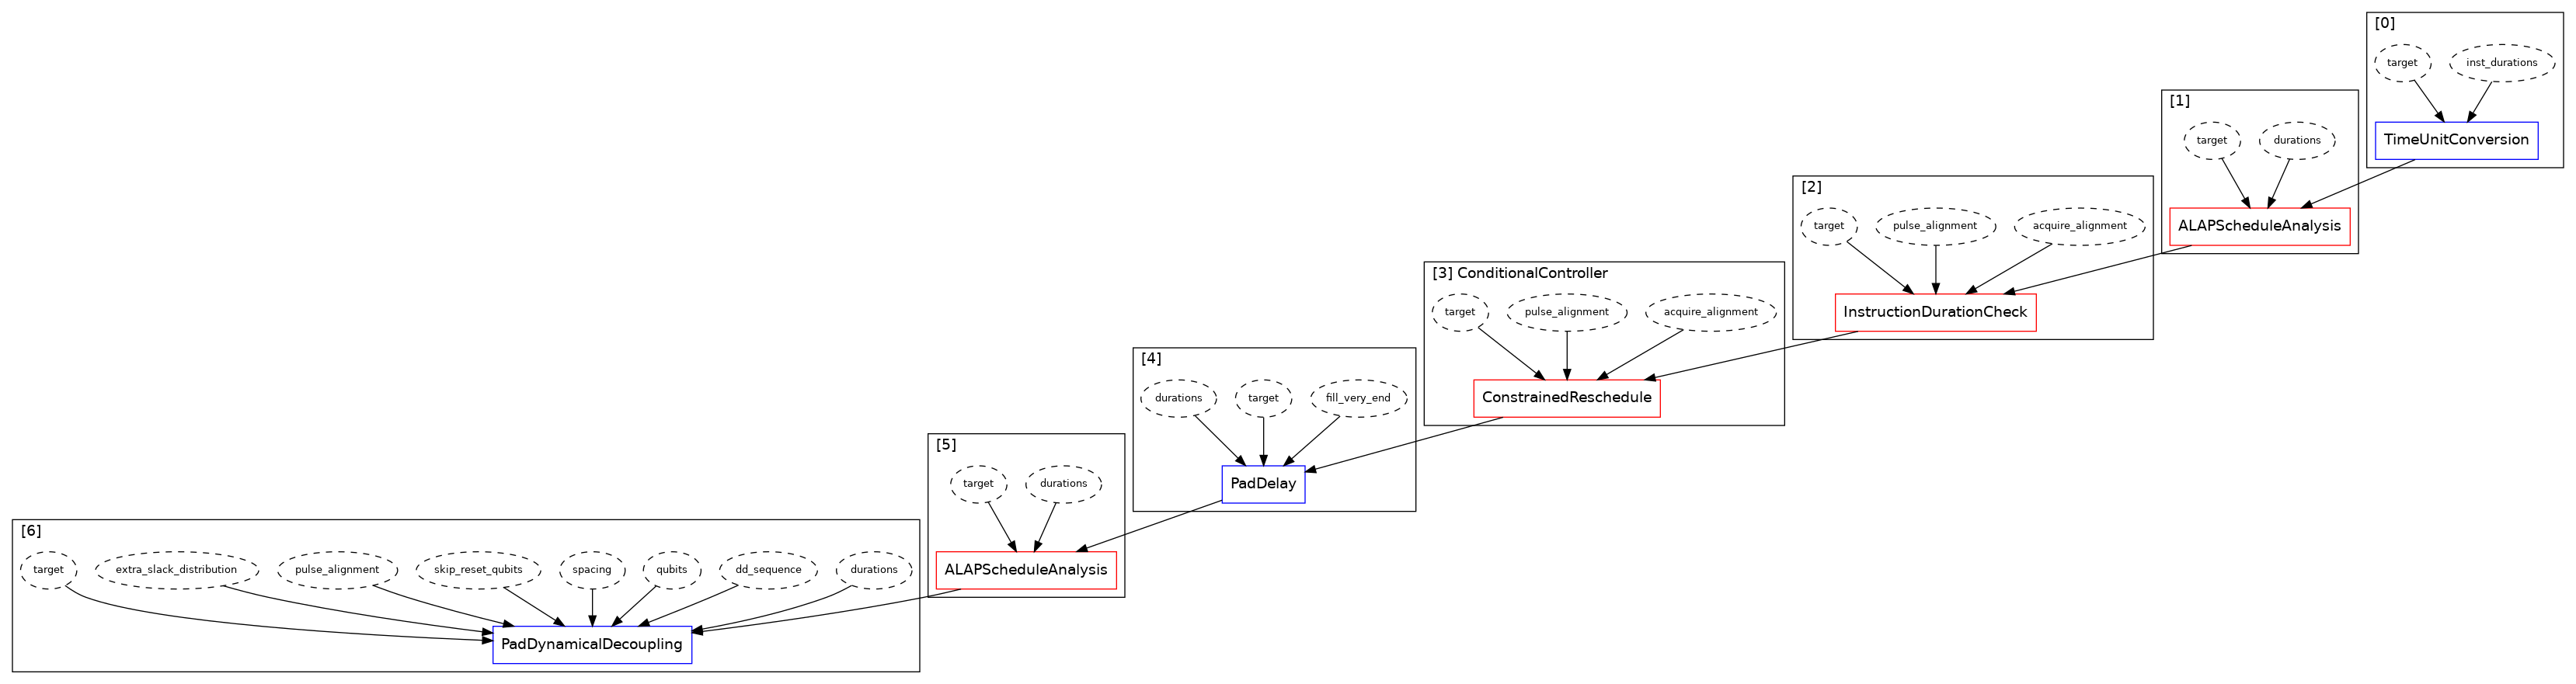

In [20]:
# PM (Schedueling) for DD circuit. 
dd_xx_pm.scheduling.draw()

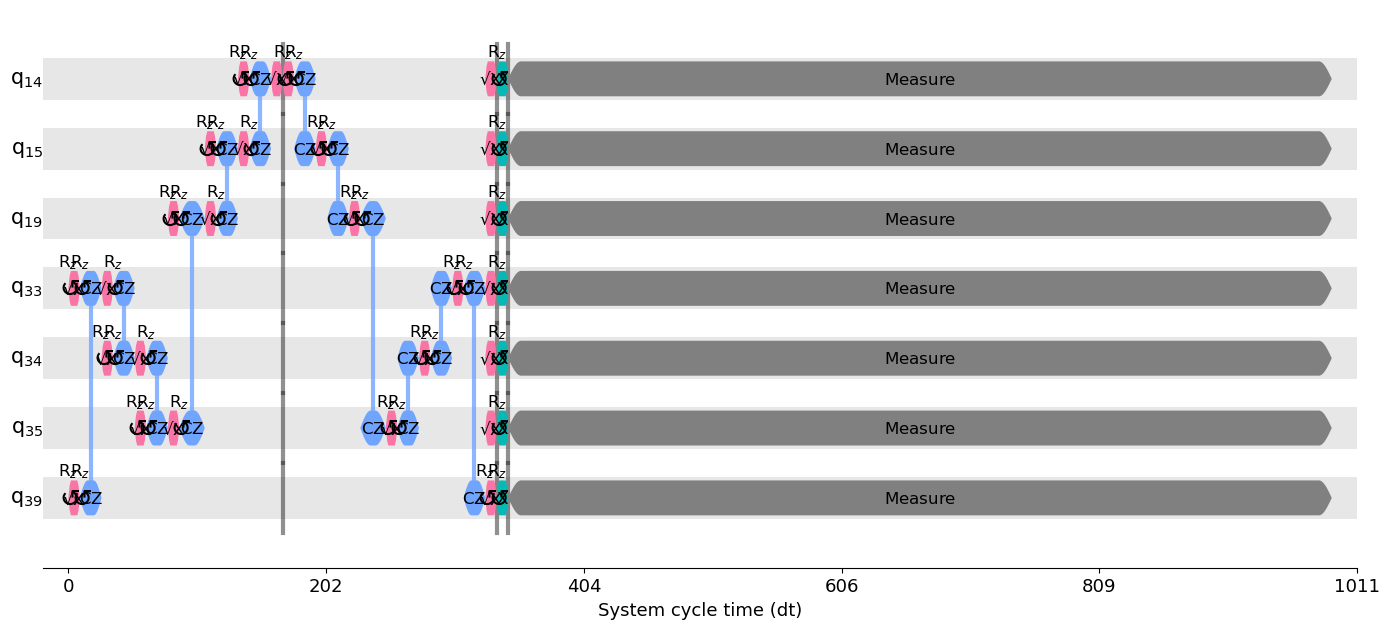

In [21]:
from qiskit.visualization import timeline_drawer
 
timeline_drawer(isa_dict["7"], idle_wires=False, target=marrakesh.target)

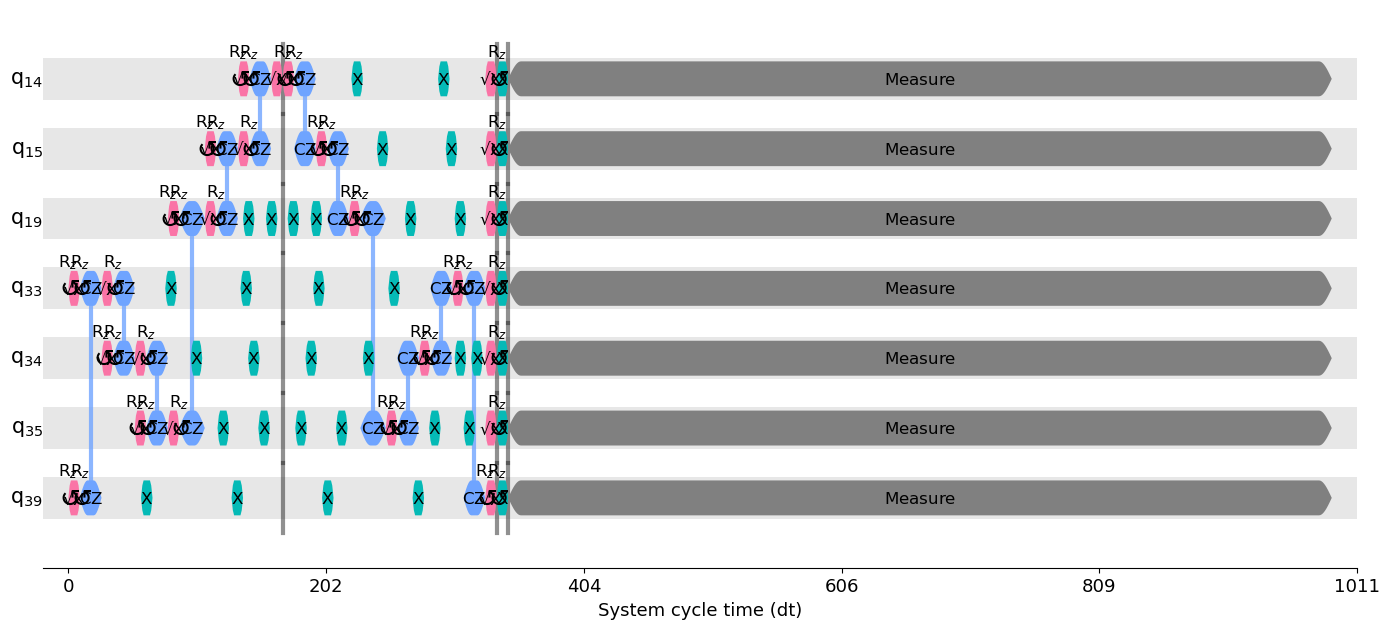

In [22]:
from qiskit.visualization import timeline_drawer
 
timeline_drawer(isa_dd_xx_dict["7"], idle_wires=False, target=marrakesh.target)

In [12]:
isa_dict["7"].draw(fold=-1)

global phase: π/2
          ┌─────────┐┌────┐ ┌───────┐                                                                                                        ┌────┐┌─────────┐ ░  ░ ┌─────────┐┌────┐┌───────┐      ┌────┐  ┌─────────┐                                                                                                                                                                                      ░ ┌───┐ ░                   ┌─┐
q_6 -> 14 ┤ Rz(π/2) ├┤ √X ├─┤ Rz(π) ├──────────────────────────────────────────────────────────────────────────────────────────────────────■─┤ √X ├┤ Rz(π/2) ├─░──░─┤ Rz(π/2) ├┤ √X ├┤ Rz(π) ├─■────┤ √X ├──┤ Rz(π/2) ├──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────░─┤ X ├─░───────────────────┤M├
          ├─────────┤├────┤ ├───────┤                                                                                    ┌────┐┌─────────┐ │ └────┘└─────────┘ ░  ░ └─────────┘└────┘└───────┘ │ ┌──┴────┴─┐└──┬────┬─┘┌───────┐      ┌────┐  ┌─────────┐                                                                                                                                                    ░ ├───┤ ░                ┌─┐└╥┘
q_5 -> 15 ┤ Rz(π/2) ├┤ √X ├─┤ Rz(π) ├──────────────────────────────────────────────────────────────────────────────────■─┤ √X ├┤ Rz(π/2) ├─■───────────────────░──░────────────────────────────■─┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├─■────┤ √X ├──┤ Rz(π/2) ├────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────░─┤ X ├─░────────────────┤M├─╫─
          ├─────────┤├────┤ ├───────┤                                                                ┌────┐┌─────────┐ │ └────┘└─────────┘                     ░  ░                              └─────────┘   └────┘  └───────┘ │ ┌──┴────┴─┐└──┬────┬─┘┌───────┐      ┌────┐  ┌─────────┐                                                                                                                  ░ ├───┤ ░             ┌─┐└╥┘ ║ 
q_4 -> 19 ┤ Rz(π/2) ├┤ √X ├─┤ Rz(π) ├──────────────────────────────────────────────────────────────■─┤ √X ├┤ Rz(π/2) ├─■───────────────────────────────────────░──░──────────────────────────────────────────────────────────────■─┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├─■────┤ √X ├──┤ Rz(π/2) ├──────────────────────────────────────────────────────────────────────────────────────────────────────────────────░─┤ X ├─░─────────────┤M├─╫──╫─
          ├─────────┤├────┤┌┴───────┴┐                                                             │ └────┘└─────────┘                                         ░  ░                                                                └─────────┘   └────┘  └───────┘ │    └────┘  └─────────┘                                                                                ┌─────────┐   ┌────┐  ┌─────────┐ ░ ├───┤ ░ ┌─┐         └╥┘ ║  ║ 
q_0 -> 32 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├─■───────────────────────────────────────────────────────────┼───────────────────────────────────────────────────────────░──░────────────────────────────────────────────────────────────────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────────────────────────────────■─┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π/2) ├─░─┤ X ├─░─┤M├──────────╫──╫──╫─
          ├─────────┤├────┤└┬───────┬┘ │ ┌────┐┌─────────┐                                         │                                                           ░  ░                                                                                                │                                                                     ┌─────────┐   ┌────┐  ┌───────┐ │ └──┬────┬─┘┌──┴────┴─┐└─────────┘ ░ ├───┤ ░ └╥┘┌─┐       ║  ║  ║ 
q_1 -> 33 ┤ Rz(π/2) ├┤ √X ├─┤ Rz(π) ├──■─┤ √X ├┤ Rz(π/2) ├─■───────────────────────────────────────┼─────────────────────

In [13]:
isa_dd_xpxm_dict["7"].draw(idle_wires=False, fold=-1)

global phase: π/2
          ┌────────────────┐┌─────────┐   ┌────┐  ┌───────┐                                                                                                                                                                                                                                                               ┌────┐       ┌─────────┐    ░  ░    ┌─────────┐   ┌────┐    ┌───────┐         ┌───────────────┐┌───┐ ┌───────────────┐┌───┐┌───────────────┐┌────┐   ┌─────────┐                                                                                                                                                                                    ░ ┌───┐ ░                   ┌─┐
q_6 -> 14 ┤ Delay(133[dt]) ├┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────■─────────────┤ √X ├───────┤ Rz(π/2) ├────░──░────┤ Rz(π/2) ├───┤ √X ├────┤ Rz(π) ├──────■──┤ Delay(28[dt]) ├┤ X ├─┤ Delay(59[dt]) ├┤ X ├┤ Delay(28[dt]) ├┤ √X ├───┤ Rz(π/2) ├────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────░─┤ X ├─░───────────────────┤M├
          ├────────────────┤├─────────┤   ├────┤  ├───────┤                                                                                                                                                                                                              ┌────┐        ┌─────────┐          │        ┌────┴────┴────┐  └─────────┘    ░  ░  ┌─┴─────────┴──┐└────┘    └───────┘      │  └──┬─────────┬──┘├───┴┐└───┬───────┬───┘└───┘├───────────────┤├───┬┘┌──┴─────────┴──┐┌───┐┌───────────────┐┌────┐   ┌─────────┐                                                                                                                                       ░ ├───┤ ░                ┌─┐└╥┘
q_5 -> 15 ┤ Delay(107[dt]) ├┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────■─────────────┤ √X ├────────┤ Rz(π/2) ├──────────■────────┤ Delay(9[dt]) ├─────────────────░──░──┤ Delay(9[dt]) ├─────────────────────────■─────┤ Rz(π/2) ├───┤ √X ├────┤ Rz(π) ├──────■──┤ Delay(22[dt]) ├┤ X ├─┤ Delay(45[dt]) ├┤ X ├┤ Delay(22[dt]) ├┤ √X ├───┤ Rz(π/2) ├───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────░─┤ X ├─░────────────────┤M├─╫─
          ├───────────────┬┘├─────────┤   ├────┤  ├───────┤                                                                                                                                                            ┌────┐        ┌─────────┐           │        ┌────┴────┴────┐   └──┬───┬──┘   ┌──────────────┐└────┬───┬─────┘┌──────────────┐ ░  ░  ├──────────────┤┌───┐  ┌──────────────┐┌───┐ ┌─┴─────────┴──┐└────┘    └───────┘      │  └──┬─────────┬──┘├───┴┐└───┬───────┬───┘└───┘├───────────────┤├───┬┘┌──┴─────────┴──┐┌───┐┌───────────────┐┌────┐   ┌─────────┐                                                                                          ░ ├───┤ ░             ┌─┐└╥┘ ║ 
q_4 -> 19 ┤ Delay(78[dt]) ├─┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────■───────┤ √X ├────────┤ Rz(π/2) ├───────────■────────┤ Delay(4[dt]) ├──────┤ X ├──────┤ Delay(9[dt]) ├─────┤ X ├──────┤ Delay(4[dt]) ├─░──░──┤ Delay(4[dt]) ├┤ X ├──┤ Delay(9[dt]) ├┤ X ├─┤ Delay(4[dt]) ├─────────────────────────■─────┤ Rz(π/2) ├───┤ √X ├────┤ Rz(π) ├──────■──┤ Delay(15[dt]) ├┤ X ├─┤ Delay(30[dt]) ├┤ X ├┤ Delay(15[dt]) ├┤ √X ├──

In [14]:
## Simulate on Aer Simulator
noiseless_backend = AerSimulator()

noiseless_pub = [(isa_dict[f"{qubit}"]) for qubit in qubits]


with Batch(backend=noiseless_backend) as batch:
    noiseless_sampler = naked_sampler(mode=batch)
    noiseless_job = noiseless_sampler.run(noiseless_pub, shots=4096)
    noiseless_result = noiseless_job.result()




/home/aashay/anaconda3/envs/qamp/lib/python3.11/site-packages/qiskit_ibm_runtime/fake_provider/local_service.py:273: UserWarning: Options {'dynamical_decoupling': {'enable': False}, 'twirling': {'enable_gates': False, 'enable_measure': False}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")


In [15]:
simulated_counts = {"7":noiseless_result[0].data.meas.get_counts(), 
                    "8":noiseless_result[1].data.meas.get_counts(),
                    "9":noiseless_result[2].data.meas.get_counts(),
                    "10":noiseless_result[3].data.meas.get_counts(),
                    "25":noiseless_result[4].data.meas.get_counts(),
                    "30":noiseless_result[5].data.meas.get_counts(),
                    "35":noiseless_result[6].data.meas.get_counts(),}
simulated_counts

{'7': {'1111111': 4096},
 '8': {'11111111': 4096},
 '9': {'111111111': 4096},
 '10': {'1111111111': 4096},
 '25': {'1111111111111111111111111': 4096},
 '30': {'111111111111111111111111111111': 4096},
 '35': {'11111111111111111111111111111111111': 4096}}

In [16]:
## PUB for experiment. Each pub has circuit(num_qubits 'q') and contains two circuits [(isa_dict['q']), (isa_dd_dict['q'])]

pub_hardware_dict = {f"{qubit}":[(isa_dict[f"{qubit}"]), (isa_dd_xx_dict[f"{qubit}"]), (isa_dd_xpxm_dict[f"{qubit}"])] for qubit in qubits}
pub_hardware_dict

{'7': [<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x75a58e1a5710>,
 '8': [<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x75a58e1d8f90>,
 '9': [<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x75a58e18a8d0>,
 '10': [<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x75a58e1db950>,
 '25': [<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x75a58e1da1d0>,
 '30': [<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x75a58e067d10>,
 '35': [<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x75a58e060290>,
  <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x75a58e06fd50>]}

# Hardware Execution Cell. Do not run unless required

In [ ]:
## Executing experiments with iterations = 3. Total circuit to run = 7*3 = 21
iterations = 3
# hardware_job_dict = {f"{iter}":{f"{qubit}":execute_on_hardware(marrakesh, pub_hardware_dict[f"{qubit}"]) for qubit in qubits} for iter in range(iterations)}

d4mttok7eg9s7398rrng
d4mttpg6ggmc738rnjl0
d4mttq9n1t7c73dgrb7g
d4mttr86ggmc738rnjng
d4mtts1n1t7c73dgrbag
d4mttss7eg9s7398rrt0
d4mtttk7eg9s7398rru0
d4mttuc7eg9s7398rs00
d4mttvch0bas73fat0fg
d4mtu01n1t7c73dgrbe0
d4mtu0g6ggmc738rnjug
d4mtu186ggmc738rnjvg
d4mtu247eg9s7398rs4g
d4mtu31n1t7c73dgrbig
d4mtu3s7eg9s7398rs6g
d4mtu4k7eg9s7398rs7g
d4mtu5ch0bas73fat0n0
d4mtu5pn1t7c73dgrbn0
d4mtu6s7eg9s7398rsb0
d4mtu7k7eg9s7398rsc0
d4mtu81n1t7c73dgrbpg


In [ ]:
hardware_job_dict = {'0': {'7': 'd4mttok7eg9s7398rrng',
  '8': 'd4mttpg6ggmc738rnjl0',
  '9': 'd4mttq9n1t7c73dgrb7g',
  '10': 'd4mttr86ggmc738rnjng',
  '25': 'd4mtts1n1t7c73dgrbag',
  '30': 'd4mttss7eg9s7398rrt0',
  '35': 'd4mtttk7eg9s7398rru0'},
 '1': {'7': 'd4mttuc7eg9s7398rs00',
  '8': 'd4mttvch0bas73fat0fg',
  '9': 'd4mtu01n1t7c73dgrbe0',
  '10': 'd4mtu0g6ggmc738rnjug',
  '25': 'd4mtu186ggmc738rnjvg',
  '30': 'd4mtu247eg9s7398rs4g',
  '35': 'd4mtu31n1t7c73dgrbig'},
 '2': {'7': 'd4mtu3s7eg9s7398rs6g',
  '8': 'd4mtu4k7eg9s7398rs7g',
  '9': 'd4mtu5ch0bas73fat0n0',
  '10': 'd4mtu5pn1t7c73dgrbn0',
  '25': 'd4mtu6s7eg9s7398rsb0',
  '30': 'd4mtu7k7eg9s7398rsc0',
  '35': 'd4mtu81n1t7c73dgrbpg'}}

hardware_job_dict_small = {'0': {'7': 'd4mttok7eg9s7398rrng',
  '8': 'd4mttpg6ggmc738rnjl0',
  '9': 'd4mttq9n1t7c73dgrb7g',
  '10': 'd4mttr86ggmc738rnjng'},
 '1': {'7': 'd4mttuc7eg9s7398rs00',
  '8': 'd4mttvch0bas73fat0fg',
  '9': 'd4mtu01n1t7c73dgrbe0',
  '10': 'd4mtu0g6ggmc738rnjug'},
 '2': {'7': 'd4mtu3s7eg9s7398rs6g',
  '8': 'd4mtu4k7eg9s7398rs7g',
  '9': 'd4mtu5ch0bas73fat0n0',
  '10': 'd4mtu5pn1t7c73dgrbn0'}}


hardware_job_dict_large = {'0':{'25': 'd4mtts1n1t7c73dgrbag',
  '30': 'd4mttss7eg9s7398rrt0',
  '35': 'd4mtttk7eg9s7398rru0'}, '1':{'25': 'd4mtu186ggmc738rnjvg',
  '30': 'd4mtu247eg9s7398rs4g',
  '35': 'd4mtu31n1t7c73dgrbig'}, '2':{'25': 'd4mtu6s7eg9s7398rsb0',
  '30': 'd4mtu7k7eg9s7398rsc0',
  '35': 'd4mtu81n1t7c73dgrbpg'}}

In [23]:
from qiskit_ibm_runtime import QiskitRuntimeService
service = QiskitRuntimeService(name="qamp-2025")

management.get:WARNING:2025-12-02 11:36:32,325: Loading saved account: qamp-2025


In [24]:

def store_data(service, job_dict, simulated):
    #           0         1       2        3          4                5                6             7                 8                   9                              10 
    # Index iteration | job_id | Qubit | shots | ideal_counts | simulated_counts | no_dd_counts | dd_xx_counts | dd_xpxm_counts | hellinger_fidelity(ideal) | hellinger_fidelity(simulated)
        
    columns_list = ["iteration", "job_id", "Qubit", "shots", "ideal_counts", "simulated_counts", "no_dd_counts", "dd_xx_counts", "dd_xpxm_counts", "hellinger_fidelity(ideal)", "hellinger_fidelity(simulated)"]
    
    df_list = []

    for iteration in job_dict.keys():

        for qubit in job_dict[iteration].keys():

            id = job_dict[iteration][qubit]

            job = service.job(id)
            result = job.result()
            
            #  iteration, id and qubits
            data_list = [iteration, id, qubit] # all are strings as they were dict keys
            
            # 2 Shots PLEASE KEEP THIS NUMBER AS EVEN
            shots = result[0].data.meas.num_shots
            data_list.append(shots)
            
            # 3 Ideal_counts
            ideal = {'1'*int(qubit):int(shots)}
            data_list.append(ideal)
            
            # 4 Simulated_counts
            simulated_counts = simulated[str(qubit)]
            data_list.append(simulated_counts)
            
            # 5 no_dd_counts
            no_dd_counts = result[0].data.meas.get_counts()
            data_list.append(no_dd_counts)
            
            # 6 dd_xx_counts
            dd_xx_counts = result[1].data.meas.get_counts()
            data_list.append(dd_xx_counts)

            # 7 dd_xpxm_counts
            dd_xpxm_counts = result[2].data.meas.get_counts()
            data_list.append(dd_xpxm_counts)


            # 8 hellinger_fidelity(ideal) and hellinger_fidelity(simulated)
            data_list += get_fidelity_for_circuit(ideal, simulated_counts, [no_dd_counts, dd_xx_counts, dd_xpxm_counts])

        
            df_list.append(data_list)

    
    df = pd.DataFrame(df_list, columns=columns_list)



    return df


In [25]:
experiment_results = store_data(service, hardware_job_dict_small, simulated_counts)

In [26]:
## Save data to .csv

experiment_results.to_csv("GHZ-Echo-on-hardware_sampler_small.csv", index=False)


## Load saved dataset. Run from here to analyze the data.


In [27]:
## Import Necessary packages here. If you are running the notebook from first cell. Leave it blank
import ast
import pandas as pd
from qiskit.visualization import plot_histogram

In [28]:

df = pd.read_csv("GHZ-Echo-on-hardware_sampler_small.csv")

df.ideal_counts = df.ideal_counts.apply(ast.literal_eval)
df.simulated_counts = df.simulated_counts.apply(ast.literal_eval)
df.no_dd_counts = df.no_dd_counts.apply(ast.literal_eval)
df.dd_xx_counts = df.dd_xx_counts.apply(ast.literal_eval)
df.dd_xpxm_counts = df.dd_xpxm_counts.apply(ast.literal_eval)
df["hellinger_fidelity(ideal)"] = df["hellinger_fidelity(ideal)"].apply(ast.literal_eval)
df["hellinger_fidelity(simulated)"] = df["hellinger_fidelity(simulated)"].apply(ast.literal_eval)
df


,iteration,job_id,Qubit,shots,ideal_counts,simulated_counts,no_dd_counts,dd_xx_counts,dd_xpxm_counts,hellinger_fidelity(ideal),hellinger_fidelity(simulated)
0,0,d4mttok7eg9s7398rrng,7,4096,{'1111111': 4096},{'1111111': 4096},"{'1010111': 6, '1111111': 3365, '1111110': 144...","{'1111111': 3438, '1111110': 128, '0111111': 4...","{'1111111': 3389, '1101111': 25, '1111011': 43...","[1.0, 0.821533203125, 0.83935546875, 0.8273925...","[0.821533203125, 0.83935546875, 0.827392578125..."
1,0,d4mttpg6ggmc738rnjl0,8,4096,{'11111111': 4096},{'11111111': 4096},"{'11111111': 3286, '11011111': 68, '11111110':...","{'11111111': 3289, '10111111': 55, '11111101':...","{'11111111': 3296, '11111010': 21, '00111111':...","[1.0, 0.80224609375, 0.802978515625, 0.8046875]","[0.80224609375, 0.802978515625, 0.8046875]"
2,0,d4mttq9n1t7c73dgrb7g,9,4096,{'111111111': 4096},{'111111111': 4096},"{'111111110': 263, '111111111': 2925, '1110111...","{'111111011': 146, '111100111': 21, '111111111...","{'111111111': 2911, '111111110': 180, '1110111...","[1.0, 0.714111328125, 0.7060546875000001, 0.71...","[0.714111328125, 0.7060546875000001, 0.7106933..."
3,0,d4mttr86ggmc738rnjng,10,4096,{'1111111111': 4096},{'1111111111': 4096},"{'1111111111': 2745, '1111110110': 10, '111011...","{'1111111111': 2706, '1111011111': 57, '011111...","{'1111111111': 2676, '1101111111': 39, '111111...","[1.0, 0.670166015625, 0.66064453125, 0.6533203...","[0.670166015625, 0.66064453125, 0.6533203125]"
4,1,d4mttuc7eg9s7398rs00,7,4096,{'1111111': 4096},{'1111111': 4096},"{'1111111': 3311, '0011110': 14, '0011111': 10...","{'1111111': 3338, '1011111': 150, '1110111': 1...","{'1111111': 3309, '0111111': 46, '1011111': 14...","[1.0, 0.8083496093750001, 0.8149414062499999, ...","[0.8083496093750001, 0.8149414062499999, 0.807..."
5,1,d4mttvch0bas73fat0fg,8,4096,{'11111111': 4096},{'11111111': 4096},"{'11101111': 44, '11111111': 3201, '11111110':...","{'11111111': 3120, '00011111': 1, '11011111': ...","{'10111111': 56, '11111111': 3184, '11111101':...","[1.0, 0.781494140625, 0.76171875, 0.77734375]","[0.781494140625, 0.76171875, 0.77734375]"
6,1,d4mtu01n1t7c73dgrbe0,9,4096,{'111111111': 4096},{'111111111': 4096},"{'111111111': 2870, '111111110': 248, '1111110...","{'111111111': 2816, '111101100': 3, '111111010...","{'111111010': 13, '111111001': 17, '111111111'...","[1.0, 0.7006835937499999, 0.6875, 0.6960449218...","[0.7006835937499999, 0.6875, 0.6960449218750001]"
7,1,d4mtu0g6ggmc738rnjug,10,4096,{'1111111111': 4096},{'1111111111': 4096},"{'0011111110': 4, '1111111111': 2771, '0111110...","{'1111111111': 2715, '1110110111': 6, '1110011...","{'1101110110': 2, '1110111111': 219, '11111111...","[1.0, 0.676513671875, 0.662841796875, 0.651855...","[0.676513671875, 0.662841796875, 0.65185546875..."
8,2,d4mtu3s7eg9s7398rs6g,7,4096,{'1111111': 4096},{'1111111': 4096},"{'1111111': 3277, '1011111': 155, '0111111': 7...","{'1111111': 3307, '1011111': 175, '1111101': 6...","{'1111111': 3319, '1111011': 42, '1101111': 22...","[1.0, 0.800048828125, 0.8073730468750001, 0.81...","[0.800048828125, 0.8073730468750001, 0.8103027..."
9,2,d4mtu4k7eg9s7398rs7g,8,4096,{'11111111': 4096},{'11111111': 4096},"{'11111111': 3168, '11111101': 175, '01111111'...","{'11111111': 3188, '11111110': 232, '11111101'...","{'11111111': 3196, '11111110': 242, '11011111'...","[1.0, 0.7734375, 0.7783203125, 0.7802734375]","[0.7734375, 0.7783203125, 0.7802734375]"


In [29]:
qubit_7 =  df[df["Qubit"] == 7 ]
qubit_8 =  df[df["Qubit"] == 8 ]
qubit_9 =  df[df["Qubit"] == 9 ]
qubit_10 =  df[df["Qubit"] == 10 ]
qubit_7


,iteration,job_id,Qubit,shots,ideal_counts,simulated_counts,no_dd_counts,dd_xx_counts,dd_xpxm_counts,hellinger_fidelity(ideal),hellinger_fidelity(simulated)
0,0,d4mttok7eg9s7398rrng,7,4096,{'1111111': 4096},{'1111111': 4096},"{'1010111': 6, '1111111': 3365, '1111110': 144...","{'1111111': 3438, '1111110': 128, '0111111': 4...","{'1111111': 3389, '1101111': 25, '1111011': 43...","[1.0, 0.821533203125, 0.83935546875, 0.8273925...","[0.821533203125, 0.83935546875, 0.827392578125..."
4,1,d4mttuc7eg9s7398rs00,7,4096,{'1111111': 4096},{'1111111': 4096},"{'1111111': 3311, '0011110': 14, '0011111': 10...","{'1111111': 3338, '1011111': 150, '1110111': 1...","{'1111111': 3309, '0111111': 46, '1011111': 14...","[1.0, 0.8083496093750001, 0.8149414062499999, ...","[0.8083496093750001, 0.8149414062499999, 0.807..."
8,2,d4mtu3s7eg9s7398rs6g,7,4096,{'1111111': 4096},{'1111111': 4096},"{'1111111': 3277, '1011111': 155, '0111111': 7...","{'1111111': 3307, '1011111': 175, '1111101': 6...","{'1111111': 3319, '1111011': 42, '1101111': 22...","[1.0, 0.800048828125, 0.8073730468750001, 0.81...","[0.800048828125, 0.8073730468750001, 0.8103027..."


In [31]:
iterations = 3
for i in range(iterations):
    print(qubit_7.iloc[i, 9])
    
print(qubit_7["hellinger_fidelity(ideal)"])
print("..............................................................................................")
for i in range(iterations):
    print(qubit_7.iloc[i, 10])
print(qubit_7["hellinger_fidelity(simulated)"])


[1.0, 0.821533203125, 0.83935546875, 0.8273925781250001]
[1.0, 0.8083496093750001, 0.8149414062499999, 0.807861328125]
[1.0, 0.800048828125, 0.8073730468750001, 0.8103027343750001]
0    [1.0, 0.821533203125, 0.83935546875, 0.8273925...
4    [1.0, 0.8083496093750001, 0.8149414062499999, ...
8    [1.0, 0.800048828125, 0.8073730468750001, 0.81...
Name: hellinger_fidelity(ideal), dtype: object
..............................................................................................
[0.821533203125, 0.83935546875, 0.8273925781250001]
[0.8083496093750001, 0.8149414062499999, 0.807861328125]
[0.800048828125, 0.8073730468750001, 0.8103027343750001]
0    [0.821533203125, 0.83935546875, 0.827392578125...
4    [0.8083496093750001, 0.8149414062499999, 0.807...
8    [0.800048828125, 0.8073730468750001, 0.8103027...
Name: hellinger_fidelity(simulated), dtype: object


### Plot counts

In [ ]:
## Just plot all counts for given qubit. 
import matplotlib.pyplot as plt

def plot_all_counts(data, qubit):
    ## For 5 iteraions only 
    iter = 5
    fig, ax = plt.subplots(nrows=iter, figsize=(20, 20))

    qubit_df = data[data["Qubit"]==qubit]
    

    plot_histogram([qubit_df.iloc[0, i] for i in range(6, 9)], legend=["no_dd", "dd_xx", "dd_xpxm"], ax=ax[0], title=f"iter:{0}")
    plot_histogram([qubit_df.iloc[1, i] for i in range(6, 9)], legend=["no_dd", "dd_xx", "dd_xpxm"], ax=ax[1], title=f"iter:{1}")
    plot_histogram([qubit_df.iloc[2, i] for i in range(6, 9)], legend=["no_dd", "dd_xx", "dd_xpxm"], ax=ax[2], title=f"iter:{2}")
    plot_histogram([qubit_df.iloc[3, i] for i in range(6, 9)], legend=["no_dd", "dd_xx", "dd_xpxm"], ax=ax[3], title=f"iter:{3}")
    plot_histogram([qubit_df.iloc[4, i] for i in range(6, 9)], legend=["no_dd", "dd_xx", "dd_xpxm"], ax=ax[4], title=f"iter:{4}")
    
    
    fig.tight_layout()            
    
    

    return fig, ax


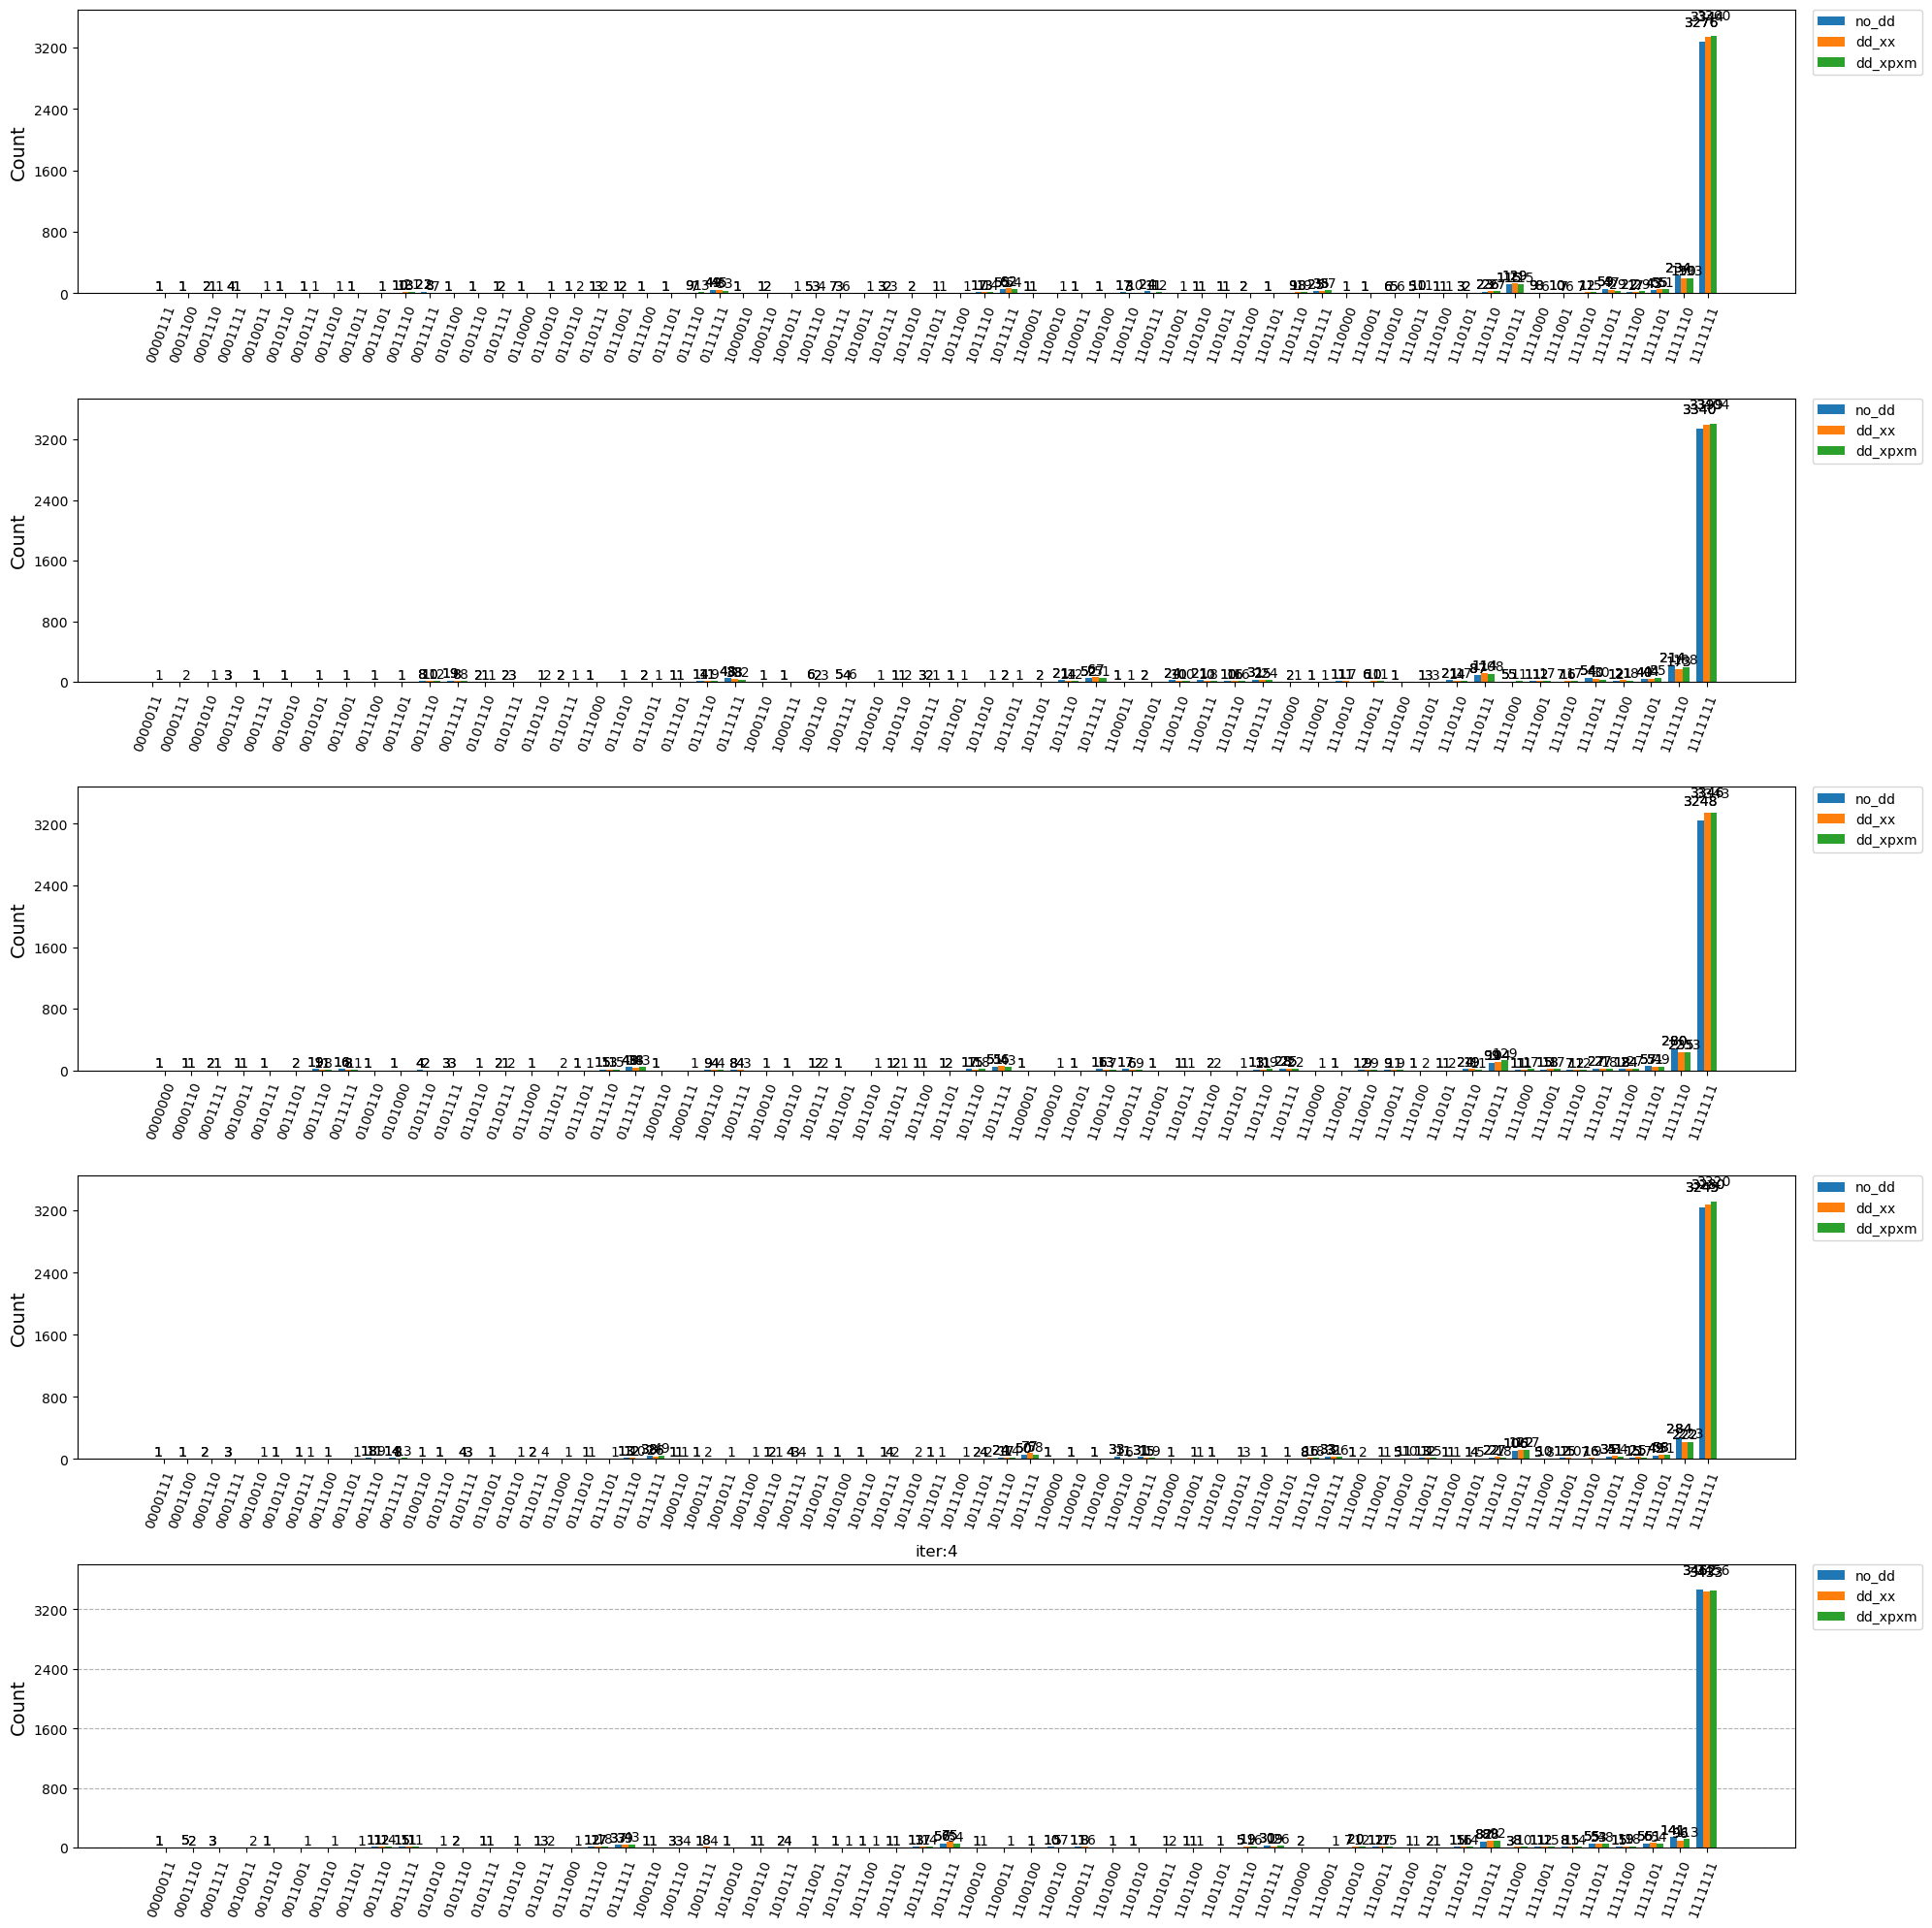

In [ ]:
fig, ax = plot_all_counts(df, 7)


### Parse the results for plot

In [41]:
def view_results_and_convert_in_array(data, qubit):
    
    qubit_df = data[data["Qubit"] == qubit]

    simulated_data = []
    no_dd_data = []
    dd_xx_data = []
    dd_xpxm_data = []
    alt_no_dd_data = []
    alt_dd_xx_data = []
    alt_dd_xpxm_data = []

    for i in range(iterations):
        hf = qubit_df.iloc[i, 9]
        alt_hf = qubit_df.iloc[i, 10]
        print(f"For qubit: {qubit} \n Hellinger Fidelity wrt ideal (simulated, no_dd, dd):\n {hf} \n Hellinger Fidelity wrt simulated (no_dd, dd):\n {alt_hf} \n")
        
        simulated_data.append(hf[0])

        simulated_data.append(hf[0])
        no_dd_data.append(hf[1])
        dd_xx_data.append(hf[2])
        dd_xpxm_data.append(hf[3])
        alt_no_dd_data.append(alt_hf[0])
        alt_dd_xx_data.append(alt_hf[1])
        alt_dd_xpxm_data.append(alt_hf[2])    

    return [simulated_data, no_dd_data, dd_xx_data, dd_xpxm_data, alt_no_dd_data, alt_dd_xx_data, alt_dd_xpxm_data]



In [42]:
view_results_and_convert_in_array(df, 7)

For qubit: 7 
 Hellinger Fidelity wrt ideal (simulated, no_dd, dd):
 [1.0, 0.821533203125, 0.83935546875, 0.8273925781250001] 
 Hellinger Fidelity wrt simulated (no_dd, dd):
 [0.821533203125, 0.83935546875, 0.8273925781250001] 

For qubit: 7 
 Hellinger Fidelity wrt ideal (simulated, no_dd, dd):
 [1.0, 0.8083496093750001, 0.8149414062499999, 0.807861328125] 
 Hellinger Fidelity wrt simulated (no_dd, dd):
 [0.8083496093750001, 0.8149414062499999, 0.807861328125] 

For qubit: 7 
 Hellinger Fidelity wrt ideal (simulated, no_dd, dd):
 [1.0, 0.800048828125, 0.8073730468750001, 0.8103027343750001] 
 Hellinger Fidelity wrt simulated (no_dd, dd):
 [0.800048828125, 0.8073730468750001, 0.8103027343750001] 



[[1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
 [0.821533203125, 0.8083496093750001, 0.800048828125],
 [0.83935546875, 0.8149414062499999, 0.8073730468750001],
 [0.8273925781250001, 0.807861328125, 0.8103027343750001],
 [0.821533203125, 0.8083496093750001, 0.800048828125],
 [0.83935546875, 0.8149414062499999, 0.8073730468750001],
 [0.8273925781250001, 0.807861328125, 0.8103027343750001]]

In [43]:

data7  = view_results_and_convert_in_array(df, 7)[1:4]
data8  = view_results_and_convert_in_array(df, 8)[1:4]
data9  = view_results_and_convert_in_array(df, 9)[1:4]
data10 = view_results_and_convert_in_array(df, 10)[1:4]


For qubit: 7 
 Hellinger Fidelity wrt ideal (simulated, no_dd, dd):
 [1.0, 0.821533203125, 0.83935546875, 0.8273925781250001] 
 Hellinger Fidelity wrt simulated (no_dd, dd):
 [0.821533203125, 0.83935546875, 0.8273925781250001] 

For qubit: 7 
 Hellinger Fidelity wrt ideal (simulated, no_dd, dd):
 [1.0, 0.8083496093750001, 0.8149414062499999, 0.807861328125] 
 Hellinger Fidelity wrt simulated (no_dd, dd):
 [0.8083496093750001, 0.8149414062499999, 0.807861328125] 

For qubit: 7 
 Hellinger Fidelity wrt ideal (simulated, no_dd, dd):
 [1.0, 0.800048828125, 0.8073730468750001, 0.8103027343750001] 
 Hellinger Fidelity wrt simulated (no_dd, dd):
 [0.800048828125, 0.8073730468750001, 0.8103027343750001] 

For qubit: 8 
 Hellinger Fidelity wrt ideal (simulated, no_dd, dd):
 [1.0, 0.80224609375, 0.802978515625, 0.8046875] 
 Hellinger Fidelity wrt simulated (no_dd, dd):
 [0.80224609375, 0.802978515625, 0.8046875] 

For qubit: 8 
 Hellinger Fidelity wrt ideal (simulated, no_dd, dd):
 [1.0, 0.78149

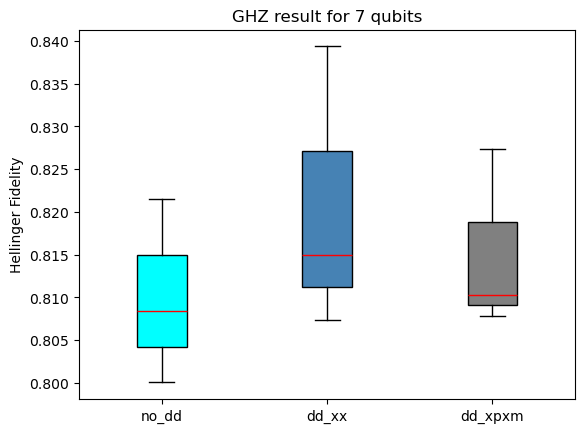

In [46]:
import matplotlib.pyplot as plt
## For 7 Qubits

labels = ['no_dd', 'dd_xx', "dd_xpxm"]
colors = ['cyan', 'steelblue', "grey"]

fig, ax = plt.subplots()
ax.set_ylabel('Hellinger Fidelity')
ax.set_title("GHZ result for 7 qubits")

bplot = ax.boxplot(data7,
                   patch_artist=True,  # fill with color
                   tick_labels=labels,
                   meanline=True, medianprops=dict(color='red'))  # will be used to label x-ticks

# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

plt.show()

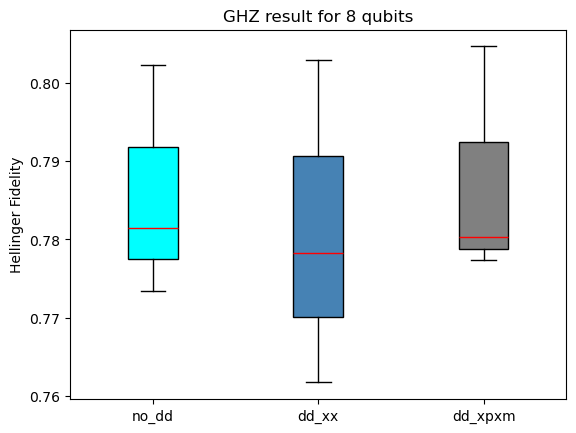

In [47]:
## For 8 Qubits

labels = ['no_dd', 'dd_xx', "dd_xpxm"]
colors = ['cyan', 'steelblue', "grey"]

fig, ax = plt.subplots()
ax.set_ylabel('Hellinger Fidelity')
ax.set_title("GHZ result for 8 qubits")

bplot = ax.boxplot(data8,
                   patch_artist=True,  # fill with color
                   tick_labels=labels,
                   meanline=True, medianprops=dict(color='red'))  # will be used to label x-ticks

# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

plt.show()

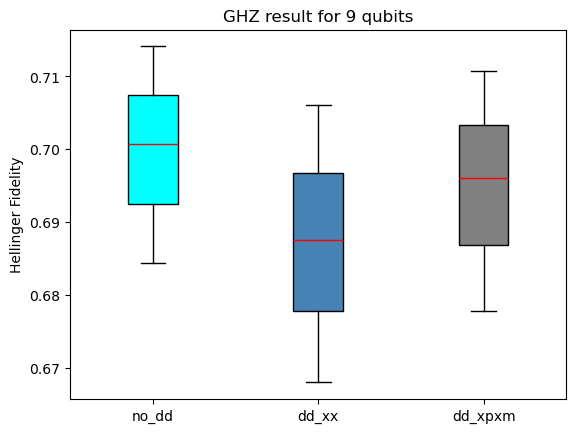

In [48]:
## For 9 Qubits

labels = ['no_dd', 'dd_xx', "dd_xpxm"]
colors = ['cyan', 'steelblue', "grey"]

fig, ax = plt.subplots()
ax.set_ylabel('Hellinger Fidelity')
ax.set_title("GHZ result for 9 qubits")

bplot = ax.boxplot(data9,
                   patch_artist=True,  # fill with color
                   tick_labels=labels,
                   meanline=True, medianprops=dict(color='red'))  # will be used to label x-ticks

# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

plt.show()

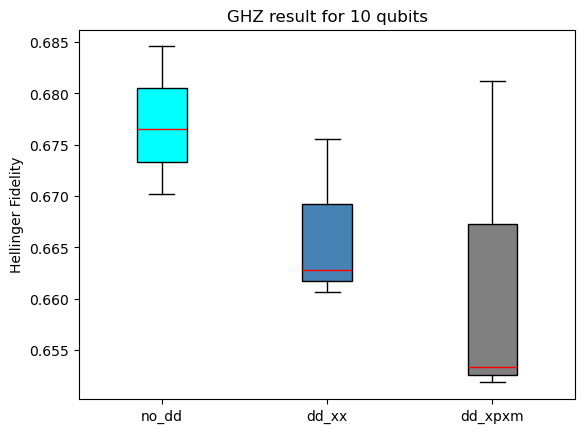

In [49]:
## For 10 Qubits

labels = ['no_dd', 'dd_xx', "dd_xpxm"]
colors = ['cyan', 'steelblue', "grey"]

fig, ax = plt.subplots()
ax.set_ylabel('Hellinger Fidelity')
ax.set_title("GHZ result for 10 qubits")

bplot = ax.boxplot(data10,
                   patch_artist=True,  # fill with color
                   tick_labels=labels,
                   meanline=True, medianprops=dict(color='red'))  # will be used to label x-ticks

# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)


plt.show()

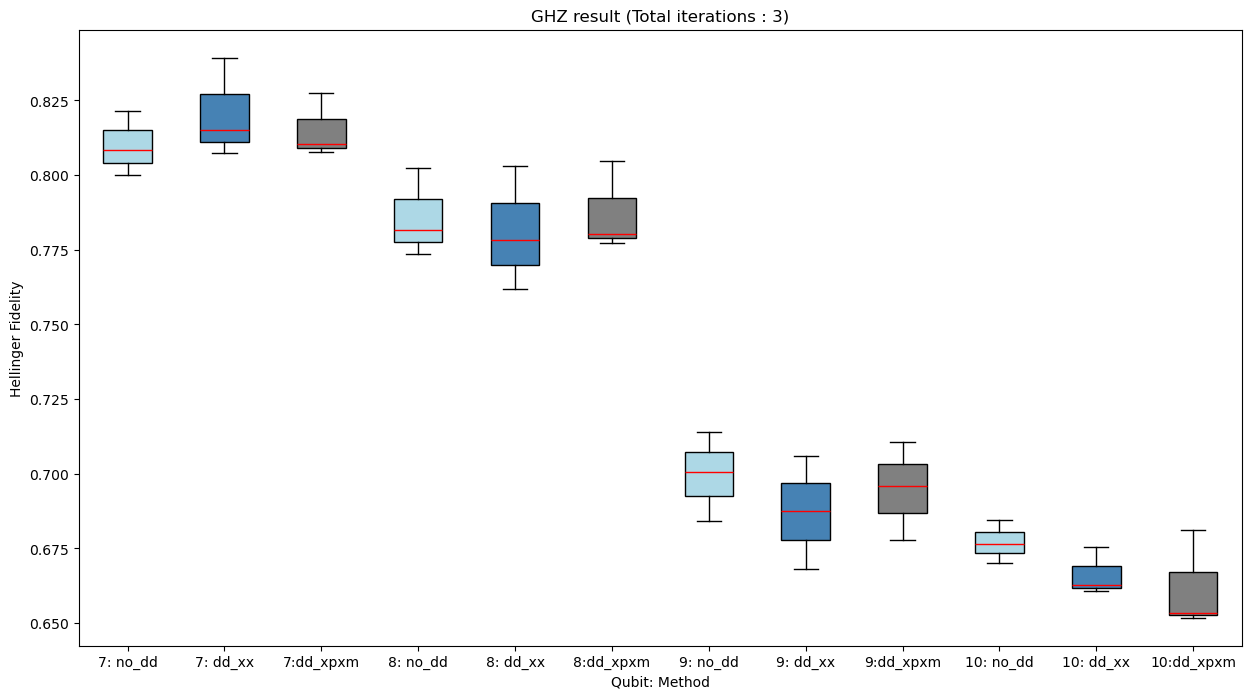

In [53]:
labels = ['7: no_dd', '7: dd_xx', '7:dd_xpxm', '8: no_dd', '8: dd_xx', '8:dd_xpxm', '9: no_dd', '9: dd_xx', '9:dd_xpxm', '10: no_dd', '10: dd_xx', '10:dd_xpxm']
colors = ['lightblue', 'steelblue', 'grey', 'lightblue', 'steelblue', 'grey', 'lightblue', 'steelblue', 'grey', 'lightblue', 'steelblue', 'grey']

fig, ax = plt.subplots(figsize=(15, 8))
ax.set_ylabel('Hellinger Fidelity')
ax.set_title(f"GHZ result (Total iterations : {iterations})")

bplot = ax.boxplot(data7+data8+data9+data10,
                   patch_artist=True,  # fill with color
                   tick_labels=labels,
                   meanline=True, medianprops=dict(color='red'), manage_ticks=True)  # will be used to label x-ticks

# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

ax.set_xlabel("Qubit: Method")
plt.savefig("Marrakesh_DD_Echo_Sampler.png")
plt.show()

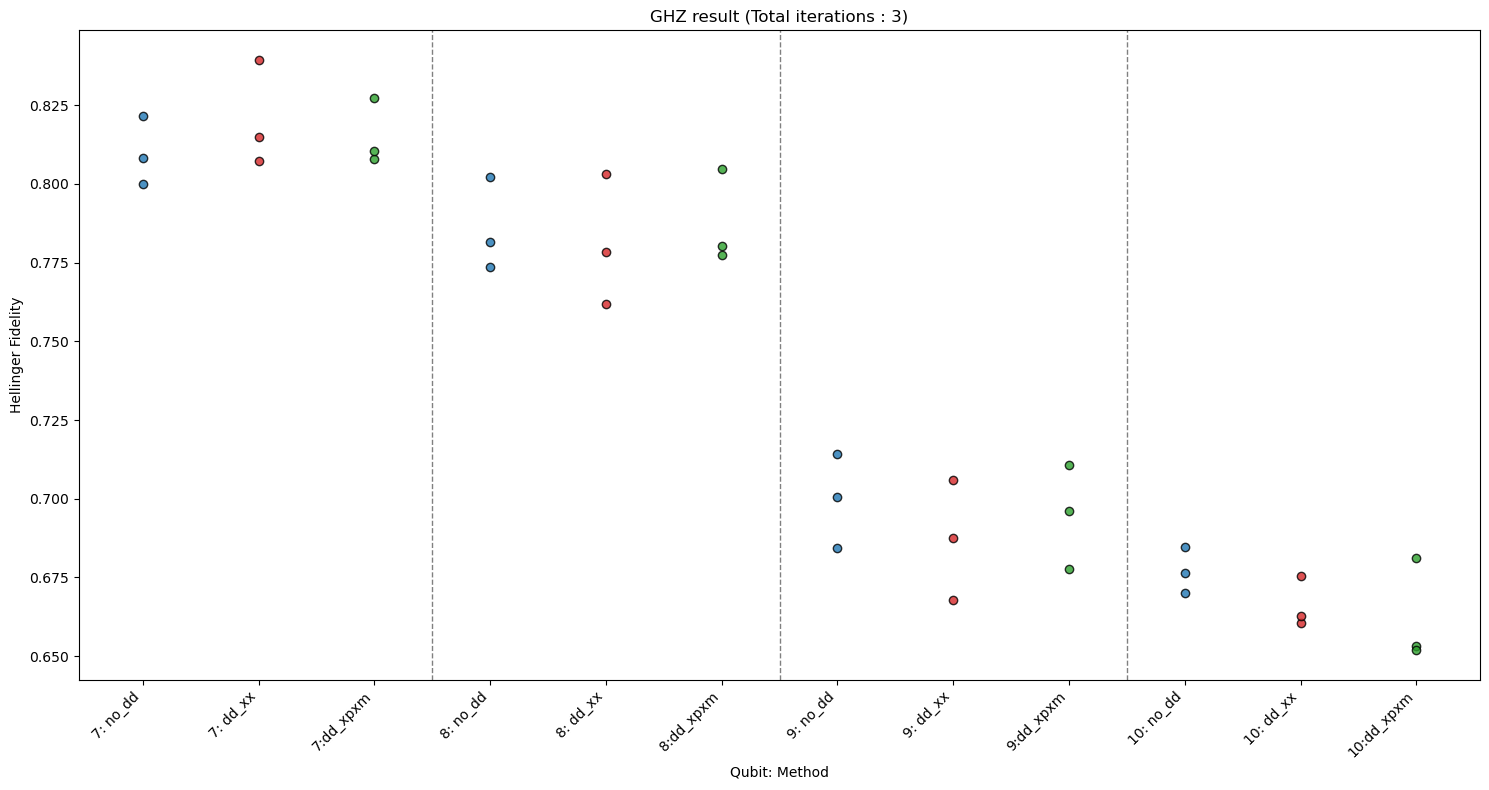

In [54]:
import numpy as np
labels = ['7: no_dd', '7: dd_xx', '7:dd_xpxm', '8: no_dd', '8: dd_xx', '8:dd_xpxm',
          '9: no_dd', '9: dd_xx', '9:dd_xpxm', '10: no_dd', '10: dd_xx', '10:dd_xpxm']

# distinct, high-contrast colors cycling per trio
colors = ['#1f77b4', '#d62728', '#2ca02c'] * 4
datasets = data7 + data8 + data9 + data10  # list of arrays/lists

fig, ax = plt.subplots(figsize=(15, 8))
ax.set_ylabel('Hellinger Fidelity')
ax.set_title(f"GHZ result (Total iterations : {iterations})")
ax.set_xlabel("Qubit: Method")

for i, (vals, label, color) in enumerate(zip(datasets, labels, colors), start=1):
    x = np.full(len(vals), i)
    jitter = x  # small horizontal spread
    ax.scatter(x, vals, color=color, edgecolor='k', alpha=0.8, label=label if i == 1 else None)

# vertical separators between qubit groups (every 3 categories)
for pos in [3.5, 6.5, 9.5]:
    ax.axvline(pos, color='gray', linestyle='--', linewidth=1)

ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels, rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [52]:
# from qiskit.transpiler.passes.scheduling import ContextAwareDynamicalDecoupling
# from qiskit.circuit.library import XGate, YGate
# from qiskit.circuit.equivalence_library import SessionEquivalenceLibrary
# from qiskit.transpiler.passes import BasisTranslator
# from qiskit_aer import AerSimulator
# from qiskit import transpile

# service = QiskitRuntimeService()
# marrakesh = service.backend("ibm_marrakesh")
# shots = 4096  # consider scaling with qubit count if variance becomes an issue

# dd_sequences = {
#     "xx": [XGate(), XGate()],
#     "xpxm": [XGate(), XGate().inverse()],
#     "xy": [XGate(), YGate()],
# }

# # Extend prepare_dd_pm to accept XY
# def prepare_dd_pm(backend: Backend, scheduling_method="alap", seq="XX"):
#     sequence = dd_sequences.get(seq.lower())
#     if sequence is None:
#         raise ValueError(f"Unknown DD sequence {seq}")
#     target = backend.target
#     pm = pm_for_backend(bknd=backend, opt_level=3, seed=42069)
#     schedule_pass = ALAPScheduleAnalysis if scheduling_method == "alap" else ASAPScheduleAnalysis
#     pm.scheduling.append(schedule_pass(target=target))
#     pm.scheduling.append(PadDynamicalDecoupling(target=target, dd_sequence=sequence))
#     return pm

# def transpile_xy_dd(circuit: QuantumCircuit, backend: Backend, scheduling_method="alap"):
#     """Translate Y to the backend basis then insert XY DD."""
#     translate = BasisTranslator(SessionEquivalenceLibrary, backend.target)
#     translated = PassManager([translate]).run(circuit)
#     xy_pm = prepare_dd_pm(backend, scheduling_method=scheduling_method, seq="XY")
#     return xy_pm.run(translated)

# def transpile_context_aware_dd(circuit: QuantumCircuit, backend: Backend, seq_key: str, scheduling_method="alap"):
#     """Context-aware DD with the chosen sequence."""
#     sequence = dd_sequences[seq_key]
#     target = backend.target
#     pm = pm_for_backend(bknd=backend, opt_level=3, seed=42069, schedueling_method=scheduling_method)
#     schedule_pass = ALAPScheduleAnalysis if scheduling_method == "alap" else ASAPScheduleAnalysis
#     pm.scheduling.append(schedule_pass(target=target))
#     # qiskit versions differ on the signature; try passing sequence, else fall back
#     try:
#         cadd_pass = ContextAwareDynamicalDecoupling(target=target, dd_sequence=sequence)
#     except TypeError:
#         cadd_pass = ContextAwareDynamicalDecoupling(target=target)
#     pm.scheduling.append(cadd_pass)
#     return pm.run(circuit)

# def aer_counts(circuit: QuantumCircuit, backend: Backend = None, shots: int = shots):
#     """Helper to get counts; when backend is provided we mimic its noise."""
#     sim = AerSimulator.from_backend(backend) if backend else AerSimulator()
#     compiled = transpile(circuit, sim)
#     return sim.run(compiled, shots=shots).result().get_counts()

# def build_pub_for_qubit(num_qubits: int):
#     """Prepare all variants for GHZ and echo-GHZ."""
#     pubs = []
#     for builder in (prepare_ghz, prepare_echo_ghz_with_xs):
#         circ = builder(num_qubits)
#         isa_no_dd = pm_for_backend(marrakesh, opt_level=3, seed=42069, schedueling_method="alap").run(circ)

#         dd_variants = [
#             prepare_dd_pm(marrakesh, seq="XX").run(circ),
#             prepare_dd_pm(marrakesh, seq="XpXm").run(circ),
#             transpile_xy_dd(circ, marrakesh, scheduling_method="alap"),
#             transpile_context_aware_dd(circ, marrakesh, "xx", scheduling_method="alap"),
#             transpile_context_aware_dd(circ, marrakesh, "xpxm", scheduling_method="alap"),
#             transpile_context_aware_dd(circ, marrakesh, "xy", scheduling_method="alap"),
#         ]

#         pubs.append([isa_no_dd, *dd_variants])
#     return pubs  # [[no-dd, xx, xpxm, xy, caxx, caxpxm, caxy] for GHZ, same for echo]



In [ ]:
# # Build pub_dict keyed by qubit count
# qubit_sizes = [7, 9, 11]  # adjust as needed
# pub_dict = {n: build_pub_for_qubit(n) for n in qubit_sizes}

# # Batch execution on hardware
# with Batch(backend=marrakesh) as batch:
#     sampler = naked_sampler(mode=batch, shots=shots)
#     flat_pubs = [c for pub in pub_dict.values() for subpub in pub for c in subpub]
#     job = sampler.run(flat_pubs)
#     job_id = job.job_id()
#     print(f"submitted batch job: {job_id}")
#     dd_counts_flat = [dist.binary_probabilities() for dist in job.result()]

# # Re-split results back into the pub_dict structure
# idx = 0
# dd_counts = {}
# for n in qubit_sizes:
#     dd_counts[n] = []
#     for _ in range(2):  # GHZ + echo
#         counts_list = dd_counts_flat[idx : idx + 7]
#         dd_counts[n].append(counts_list)  # same order as build_pub_for_qubit
#         idx += 7

# # Hellinger fidelities
# fidelity_summary = {}
# for n in qubit_sizes:
#     fidelity_summary[n] = []
#     for subpub_idx, pub_counts in enumerate(dd_counts[n]):
#         base_circ = (prepare_ghz if subpub_idx == 0 else prepare_echo_ghz_with_xs)(n)
#         ideal_counts = aer_counts(base_circ, backend=None, shots=shots)
#         simulated_counts = aer_counts(base_circ, backend=marrakesh, shots=shots)
#         fidelity_summary[n].append(
#             get_fidelity_for_circuit(ideal_counts, simulated_counts, pub_counts)
#         )

# fidelity_summary  # [[[H_sim, H_noDD, H_xx, ...], [H_noDD_vs_sim, ...]] for each circuit per qubit count]
